<a href="https://colab.research.google.com/github/EsserMishelle/Applied-Data-Science-ML/blob/main/Income_Analysis_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

income
<=50K    0.7592
>50K     0.2408
Name: proportion, dtype: float64
1 4
The largest accuracy and depth of the test data are: 0.8657 and 22
                              feature  importance
3                        capital-gain       0.130
30  marital-status_Married-civ-spouse       0.115
0                                 age       0.112
2                       education-num       0.094
1                              fnlwgt       0.078
5                      hours-per-week       0.069


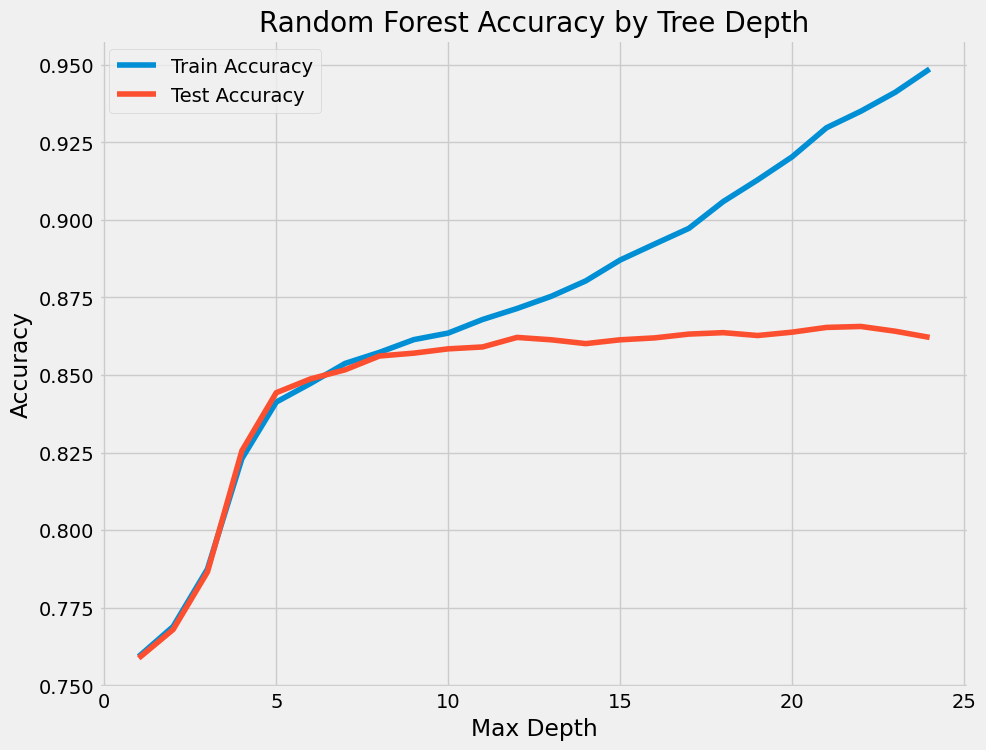

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import models from scikit learn module:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, RandomForestRegressor
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

feature_cols = ['age', 'workclass', 'fnlwgt','education', 'education-num',
'marital-status', 'occupation', 'relationship', 'race', 'sex',
'capital-gain','capital-loss', 'hours-per-week','native-country', 'income']

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, header=None, names = feature_cols)

# Raw data
df_raw = df.copy()

# Cleaned data
df = df.copy()
df.head()

#Clean columns by stripping extra whitespace for columns of type "object"
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# Find out the income distribution among > 50K or <= 50K
print(round(df['income'].value_counts(normalize=True), 4) )

#Create feature dataframe X with feature columns and dummy variables for categorical features

# Create feature matrix (drop target first)
X = df[feature_cols].drop(columns=['income'])

# One-hot encode the categorical features
X = pd.get_dummies(X, drop_first=True)

#Create output variable y which is binary, 0 when income is less than 50k, 1 when it is greather than 50k
y = df['income'].map({'<=50K': 0, '>50K': 1})

#Split data into a train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state= 42)

#Instantiate random forest classifier, fit and score with default parameters
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
rfc_score =rfc.score(X_test, y_test)
print(round(rfc_score), 4)

#Tune the hyperparameter max_depth over a range from 1-25, save scores for test and train set

accuracy_train=[]
accuracy_test = []

for depth in range(1,25):
  rfc_25 = RandomForestClassifier(max_depth = depth, random_state=0)
  rfc_25.fit(X_train, y_train)
  accuracy_train.append(rfc_25.score(X_train, y_train))
  accuracy_test.append(rfc_25.score(X_test, y_test))

#Find the best accuracy and at what depth that occurs
best_accuracy = np.max(accuracy_test)
best_depth = np.argmax(accuracy_test)+1
print(f'The largest accuracy and depth of the test data are: {best_accuracy.round(4)} and {best_depth}')

#Plot the accuracy scores for the test and train set over the range of depth values
depths = range(1, 25)

plt.style.use('fivethirtyeight')
plt.figure(figsize=(10,8))

plt.plot(depths, accuracy_train, label='Train Accuracy')
plt.plot(depths, accuracy_test, label='Test Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Max Depth')
plt.title('Random Forest Accuracy by Tree Depth')
plt.legend()

#Save the best random forest model and save the feature importances in a dataframe
best_rf = RandomForestClassifier(max_depth=best_depth, random_state=0)

best_rf.fit(X_train, y_train)
best_rf.score(X_test, y_test)
feature_importance_df = pd.DataFrame({
  'feature': X_train.columns,
  'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).round(3)
print(feature_importance_df[:6])

['College to Bachelors', 'HS or less', 'Masters or more']
Categories (3, object): ['HS or less' < 'College to Bachelors' < 'Masters or more']
The largest accuracy and depth of the test data are: 0.8666 and 21
0.9339296683046683
0.8653462306156917
                              feature  importance
3                        capital-gain       0.134
30  marital-status_Married-civ-spouse       0.134
0                                 age       0.106
2                       education-num       0.078
1                              fnlwgt       0.076


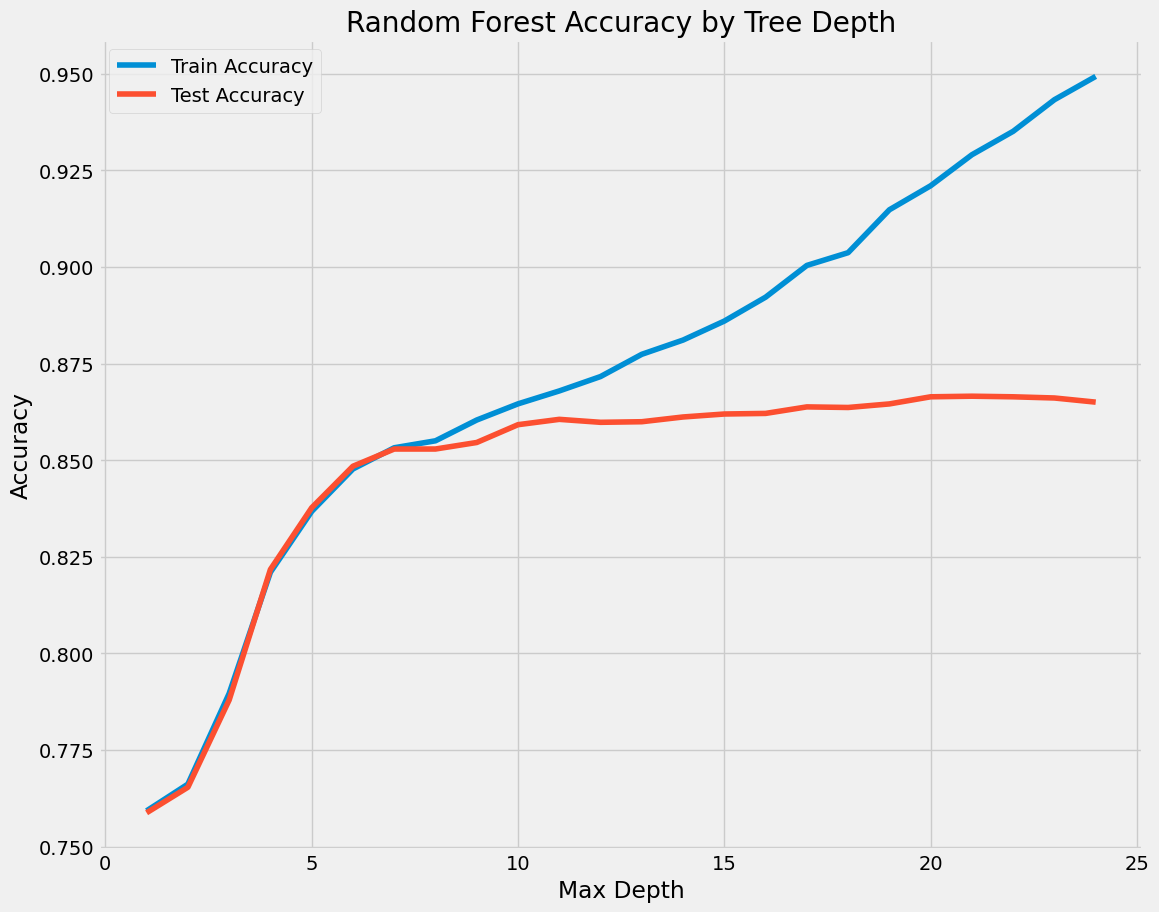

In [18]:
#Create two new features, based on education and native country
# Aggregate native- country into US and non US
df["native-country-agg"] = df["native-country"].apply(lambda cell: "US" if cell == "United-States" else "Non-US" )

# Bin education-num into 3 bins
df['education'].unique()

# array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th',
#        'Some-college', 'Assoc-acdm', 'Assoc-voc', '7th-8th',
#        'Doctorate', 'Prof-school', '5th-6th', '10th', '1st-4th',
#        'Preschool', '12th'], dtype=object)

df['education_bin'] =pd.cut(df['education-num'], [0,9,13,16],labels=['HS or less', 'College to Bachelors', 'Masters or more'])

print(df['education_bin'].unique())


feature_cols = ['age',
       'capital-gain', 'capital-loss', 'hours-per-week', 'sex', 'race','education_bin', 'native-country-agg']

X = df[feature_cols]
X = pd.get_dummies(X, drop_first=True)
y= df['income']

accuracy_train=[]
accuracy_test = []

for depth in range(1,25):
  rfc_25 = RandomForestClassifier(max_depth = depth)
  rfc_25.fit(X_train, y_train)
  accuracy_train.append(rfc_25.score(X_train, y_train))
  accuracy_test.append(rfc_25.score(X_test, y_test))

#Find the best accuracy and at what depth that occurs
best_accuracy = np.max(accuracy_test)
best_depth = np.argmax(accuracy_test)+1
print(f'The largest accuracy and depth of the test data are: {(best_accuracy).round(4)} and {best_depth}')


#Plot the accuracy scores for the test and train set over the range of depth values
depths = range(1, 25)

plt.style.use('fivethirtyeight')
plt.figure(figsize=(12,10))

plt.plot(depths, accuracy_train, label='Train Accuracy')
plt.plot(depths, accuracy_test, label='Test Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Max Depth')
plt.title('Random Forest Accuracy by Tree Depth')
plt.legend()

#Save the best random forest model and save the feature importances in a dataframe
best_rf = RandomForestClassifier(max_depth=22)
best_rf.fit(X_train, y_train)
best_rf.score(X_test, y_test)
print(best_rf.score(X_train, y_train))
print(best_rf.score(X_test, y_test))

feature_importance_df = pd.DataFrame({
  'feature': X_train.columns,
  'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).round(3)
print(feature_importance_df[:5])